<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> A. Supervisado </p> Modelos de Regresión  </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Diplomado Ciencia de Datos</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> 1. Introducción </FONT>

**Modelo de regresión:** es el modelo en el que se busca establecer la relación entre un cierto número de características y una variable objetivo continua. Es decir, la relación entre la variable dependiente $y$ y las variables predictoras $x_1, x_2 , \dots , x_n$.

A continuación, definiremos las librerías necesarias para trabajar regresión

In [2]:
# Para gráficos y data.frames
import pandas as pd
import numpy  as np

# librerías para graficar
import plotly.express     as px
import matplotlib.pyplot  as plt
import seaborn            as sns


# Dividir los datos entrenamiento y prueba
from sklearn.model_selection     import train_test_split
from sklearn.feature_selection   import RFE

# Para preprocesamiento: escalador
from sklearn.preprocessing       import StandardScaler

# Modelo de regresión
from sklearn.linear_model        import LinearRegression
from sklearn.svm                 import SVR
from sklearn.neighbors           import KNeighborsRegressor
from sklearn.tree                import DecisionTreeRegressor
from sklearn.ensemble            import RandomForestRegressor

# Métricas
from sklearn                     import metrics
from sklearn.metrics             import mean_squared_error, r2_score, mean_absolute_error

# warnings
import warnings
warnings.filterwarnings('ignore')

# <FONT SIZE=5 COLOR="purple"> 2. Conceptos básicos de Machine Learning: Regresión </FONT>

En está sección revisaremos algunos conceptos básicos de machine learning.

<FONT SIZE=3 COLOR="green"> a. Algoritmos de regresión: </FONT>  técnicas de aprendizaje supervisado para hacer predicciones sobre una variable objetivo $\mathbf{y}$ que es numérica continua, es decir, toma valor en un intervalo.


<center><FONT SIZE=4 COLOR="BLUE">Situación 1: Predicción ventas </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/ef2f70be5b4059198fa6d856ae1ad0b9802960df/supervisado4.png?raw=true" alt="centered image" width="300" height="150"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><FONT SIZE=4 COLOR="BLUE">Situación 2: Predicción precio apartamento </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/34ca9d1b545bc223a6505754189ac5499fdbc560/intro_regresion_1.jpg?raw=true" alt="centered image" width="300" height="150"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=3 COLOR="green"> b. Variable Objetivo: </FONT> también denominada **variable de respuesta**. En un algoritmo de aprendizaje de máquina supervisado, es la variable que queremos predecir (por lo general, denotada como $\mathbf{y}$).
<br>

<FONT SIZE=3 COLOR="green"> c. Variable(s) Predictora(s): </FONT> también denominada ***features*** o características, son las variables que se usarán para predecir la variable objetivo. Estas se denotan como

$$\mathbf{X}=\{X_1,X_2, \dots, X_n \}$$

<br>

<FONT SIZE=3 COLOR="green"> d. Conjunto de Entrenamiento: </FONT> es el subconjunto de registros que se selecciona para entrenar el modelo. Este conjunto consta de dos partes:

- $X_{train}$ : conjunto de entrenamiento de los predictores o *features*.

- $y_{train}$: conjunto de entrenamiento de la variable objetivo asociada al conjunto $X_{train}$.

El conjunto de entrenamiento se selecciona de manera aleatoria y por lo general se toma el $70\%$ , $75\%$ y $80 \%$.

<br>

<FONT SIZE=3 COLOR="green"> e. Conjunto de Prueba: </FONT>: Es el subconjunto de registros que se selecciona para validar el modelo. Consta de dos partes:

- $X_{test}$ : conjunto de validación de los predictores o *features*.

- $y_{test}$: conjunto de validación de la variable objetivo asociada al conjunto $X_{test}$.

El tamaño de este conjunto es el complemento del conjunto de entrenamiento.

**Nota:** para algoritmos clásicos de machine learning se acostumbra dividir en entrenamiento y prueba. Sin embargo, en algoritmos más complejos que requieren el entrenamiento de mucho parámetros, como es el caso de las redes neuronales, se acostumbra dividir en tres partes: *train* , *validation* and *test*.

<center><FONT SIZE=4 COLOR="BLUE"> Esquema general de modelos supervisados en Machine Learning </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/209c0394fc9518a5c7331d550d5606bf355c5707/esquema_modelos.jpg?raw=true" alt="centered image" width="500" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=4 COLOR="blue"> Algunos modelos de regresión </FONT>

Dentro de la bateria de modelos usados para regresión tenemos

1. Regresión lineal simple.

2. Regresión lineal múltiple

3. knn (k-vecinos más cercanos)

4. Árboles de Decisión

5. SVR: máquina de vectores de soporte para regresión

6. Random Forest


# <FONT SIZE=5 COLOR="purple"> 3. Modelo de Regresión </FONT>

En esta sección revisaremos los modelos de

- Regresión lineal

- k-vecinos más cercanos para regresión

- árboles de decisión para regresión









## <FONT SIZE=4 COLOR="green"> 3.1 Covarianza </FONT>

La covarianza es el valor que refleja en que medida dos variables aleatorias varian de forma conjunta respecto a sus medias.

De acuerdo con lo anterior, la covarianza está dada por la siguiente fórmula

$$Muestra: Cov(X,Y)=S_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{n-1}$$

$$Poblacion:COV(X,Y)=\sigma_{XY}=\dfrac{\sum \limits_{i=1}^N (x_i-\mu_x)(y_i-\mu_y)}{N}$$

donde $\overline{x}$ y $\overline{y}$ son las medias de las variables $X$ y $Y$ respectivamente y $n$ es el total de observaciones.

A continuación listaremos algunas propiedades de la covarianza

- $Cov(X,c)=0$, donde $c$ es una constante.

- $Cov(X,X)=Var(X)$, la covarianza de una variable con si misma es la varianza de la variable.

- $Cov(X,Y)=C(Y,X)$, la varianza es simétrica, es decir, no importa el orden en que se coloquen la variables.

- La covarianza mide la fuerza de la relación lineal entre dos variables.

- Una alta covarianza no implica efecto causal.

**Interpretación de la covarianza**

- $Cov(X,Y)>0$ ; las variables $X$ y $Y$ tienden a moverse en la misma dirección.

- $Cov(X,Y)<0$   las variables $X$ y $Y$ tienden a moverse en direcciones opuestas.

- $Cov(X,Y)=0$: las variables $X$ y $Y$ no estan relacionadas linealmente.

## <FONT SIZE=4 COLOR="green"> 3.2 Coeficiente de Correlación </FONT>

El coeficiente de correlación se define como

$$muestra: r_{xy}=\dfrac{S_{xy}}{S_xS_y} \qquad \qquad poblacion : \rho_{xy}=\dfrac{\sigma_{xy}}{\sigma_{x}\sigma_{y}}$$

lo que es equivalente a

$$r_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{\left (\sum \limits_{i=1}^n (x_i-\overline{x})^2 \right)^{1/2} \left ( \sum \limits_{i=1}^n (y_i-\overline{y})^2 \right)^{1/2}}$$

Veamos la interpretación de los diferentes valores del coeficiente de correlación de Pearson, teniendo en cuenta que:

$$-1 \leq r_{xy} \leq 1 $$

- Si $r_{xy}=1$, hay una relación positiva perfecta, es decir, indica una dependencia total entre las variables de manera directa. Si una de ellas aumenta, la otra también lo hace en proporción constante. Es decir, la relación es lineal.

- Si $0<r_{x,y}<1$, existe una correlación positiva.

- Si $r_{x,y}=0$, no existe relación lineal. Pero pueden haber otro tipo de relaciones.

- Si $-1<r_{x,y}<0$, existe una correlación negativa.

- Si $r_{x,y}=-1$, existe una correlación negativa perfecta, es decir, indica una dependencia total de manera inversa. Si una variable disminuye la otra aumenta en proporción constante.


<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/da5b836cf8bee14fa8ca4ffa3e53dd97c41136ea/regresi%C3%B3n4.png?raw=true" alt="centered image" width="400" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


Algunas propiedades para tener en cuenta del coeficiente de correlación:

- No depende de las unidades de las variables.

- El coefiente de Pearson es acotado

## <FONT SIZE=4 COLOR="green"> 3.3 Modelo de regresión lineal simple </FONT>

Supongamos que tenemos dos variables cuantitativas, que representan en el plano un conjunto de puntos $(x,y)$. En general, estos puntos no tienen porque estar ajustados de forma lineal, es decir, el diagrama de dispersión no tiene porque representar una recta.

Sin embargo, existen situaciones en que los puntos se aproximan o se ajustan en mayor medida a una línea recta. Particualmente cuando el coeficiente de correlación es cercano a 1 o a -1.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/676fc5569462ef54d082e0a8f9fbf38686efc298/Regresi%C3%B3n/regresion1.png?raw=true" alt="centered image" width="550" height="350"></center>
<br>

La idea es encontrar una recta que se aproxime a los puntos dados

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/676fc5569462ef54d082e0a8f9fbf38686efc298/Regresi%C3%B3n/regresion2.png?raw=true" alt="centered image" width="550" height="300"></center>
<br>

Para hallar la ecuación de la recta que se observa en el gráfico se puede usar:

- Método de los mínimos cuadrados.

- Descenso del gradiente







## <FONT SIZE=4 COLOR="green"> 3.4 Modelo de knn para regresión </FONT>

En lugar de clasificar una muestra, el knn para regresión predice un valor numérico, como sigue:

1. **Identificación de los vecinos más cercanos**: Dado un nuevo punto de datos, el algoritmo busca los **k** puntos más cercanos en el espacio de características (según una medida de distancia como la euclidiana).
   
2. **Cálculo del valor predicho**: El valor de salida para el punto nuevo se calcula promediando los valores de las etiquetas de los **k** vecinos más cercanos. Es decir:
$$   \hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i $$
   
donde $ y_i $ son las etiquetas de los k-vecinos más cercanos.

3. **Suavizado del resultado**: Como resultado, el valor de salida es continuo, lo que convierte al tree en una técnica válida para regresión.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/9560be97d66e196d7b0a03cc9fb3d69f1d393ba4/regresion_5.jpg?raw=true" alt="centered image" width="400" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

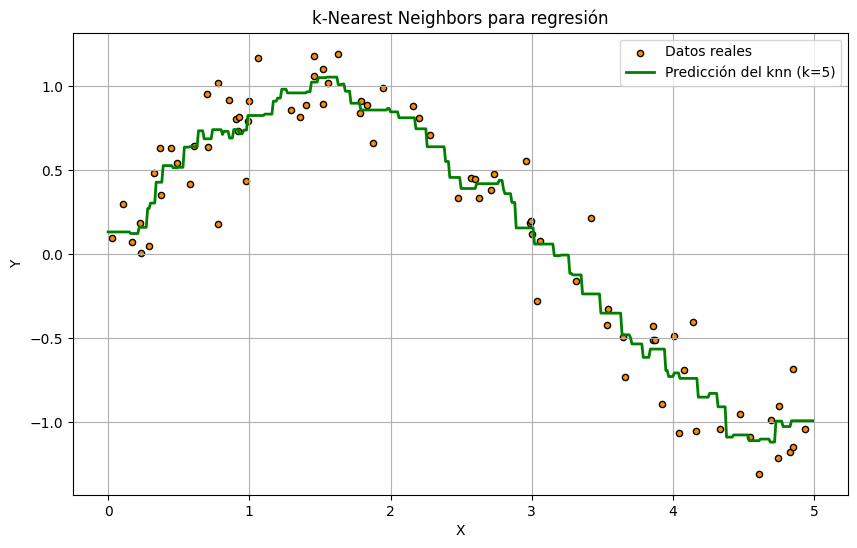

In [ ]:
# Generamos datos de ejemplo
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(80) * 0.2

# Creamos un modelo de tree para regresión
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X, y)

# Predicciones
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_knn_pred = knn_regressor.predict(X_test)

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos reales")
plt.plot(X_test, y_knn_pred, color="green", label="Predicción del knn (k=5)", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("k-Nearest Neighbors para regresión")
plt.legend()
plt.grid(True)

plt.show()

## <FONT SIZE=4 COLOR="green"> 3.5 Modelo de Árboles de Decisión para regresión </FONT>

En los árboles de decisión para regresión, el procedimiento también cambia respecto al de clasificación:

1. **División del conjunto de datos**: El árbol se construye dividiendo el conjunto de datos en ramas con base en los valores de las características. Sin embargo, en lugar de buscar divisiones que maximicen la ganancia de información o el índice de Gini (usado en clasificación), en regresión se busca minimizar la **varianza** o el **error cuadrático medio** (MSE, por sus siglas en inglés).

2. **Predicción**: Una vez que el árbol está entrenado, la predicción para un nuevo punto de datos se realiza navegando por el árbol desde la raíz hasta una hoja. El valor en la hoja no es una clase, sino un valor promedio de las etiquetas de los datos que caen en esa hoja.

3. **Criterio de división**: Para cada nodo, el árbol selecciona la característica y el punto de división que minimicen la suma del error cuadrático medio en los subconjuntos hijos.

El modelo final hace una predicción basada en los valores promedio de los datos en los nodos terminales, obteniendo así una predicción numérica.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/9560be97d66e196d7b0a03cc9fb3d69f1d393ba4/regresion_6.jpg?raw=true" alt="centered image" width="400" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

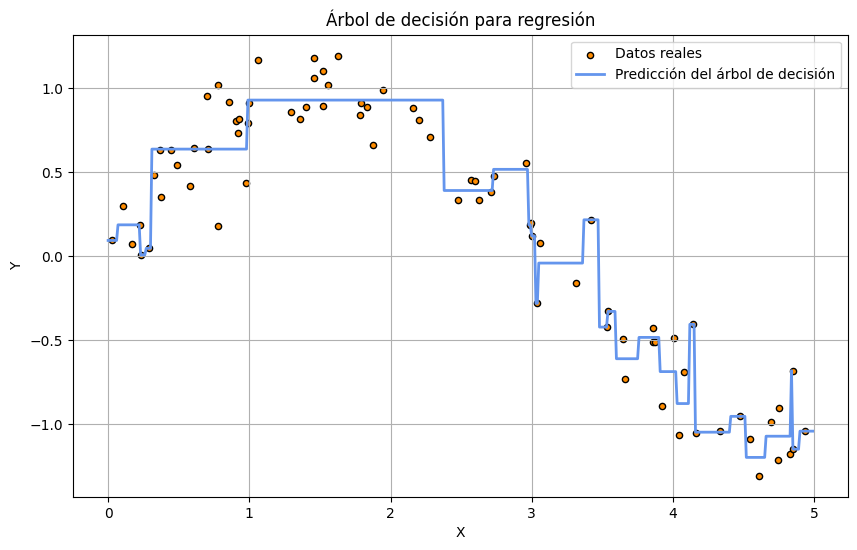

In [ ]:
# Generamos datos de ejemplo
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(80) * 0.2

# Ajustamos un árbol de decisión para regresión
tree_regressor = DecisionTreeRegressor(max_depth=5)
tree_regressor.fit(X, y)

# Predicciones
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = tree_regressor.predict(X_test)

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos reales")
plt.plot(X_test, y_pred, color="cornflowerblue", label="Predicción del árbol de decisión", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Árbol de decisión para regresión")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# profundidad del arbol tree_regressor.
tree_regressor.get_depth()

4

Profundidad del árbol: 4
Número de nodos terminales: 16


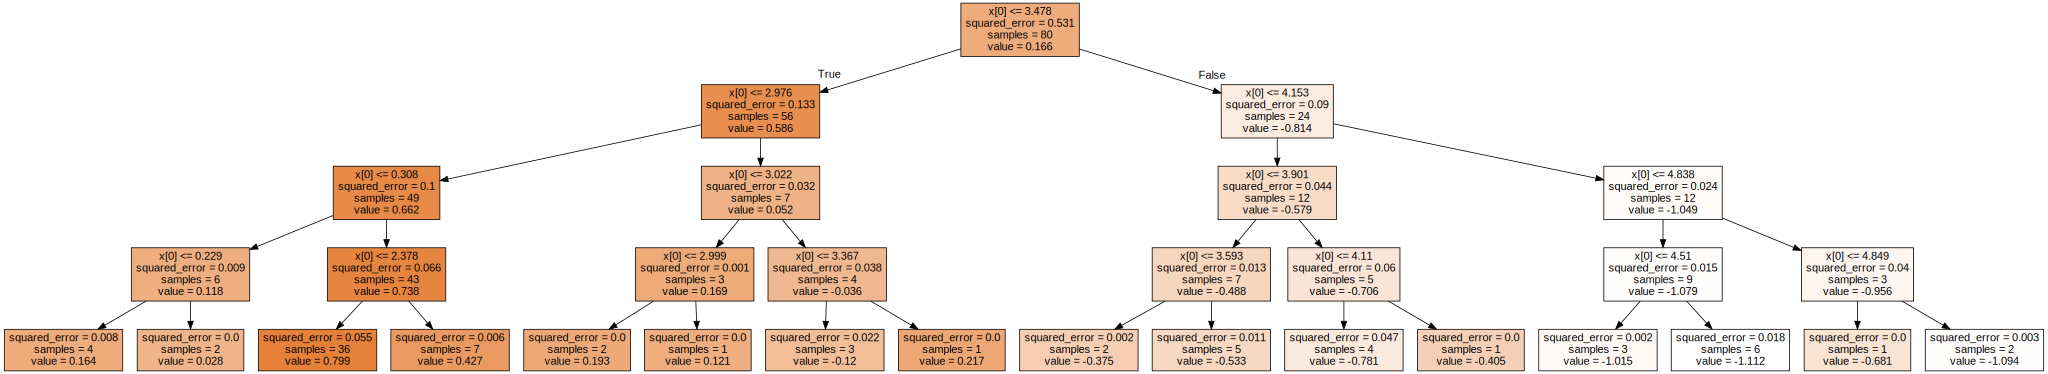

In [ ]:
# graficar el árbol completo
from sklearn.tree             import export_graphviz
from graphviz                 import Source

# Revisamos la profundidad y el número de nodos terminales
print(f"Profundidad del árbol: {tree_regressor.get_depth()}")
print(f"Número de nodos terminales: {tree_regressor.get_n_leaves()}")
# Generamos el árbol
dot_data = export_graphviz(tree_regressor,                           # modelo
                           filled=True,)                         # colores del árbol (relleno)
Source(dot_data, format="png")

**Comparación**:
- En **tree para regresión**, la predicción es un promedio de los vecinos cercanos.
- En **árboles de decisión para regresión**, la predicción es el valor promedio de los datos en las hojas del árbol.

# <FONT SIZE=5 COLOR="purple"> 4. Evaluación de un modelo de regresión </FONT>

En esta sección revisaremos la forma en que se evalúa un modelo de regresión.

***MSE : Error cuadrático medio***

Matemáticamente, el $MSE$ se puede calcular como la suma promedio de la diferencia al cuadrado entre el valor real y el valor previsto o estimado representado por el modelo de regresión (línea o plano).

<center><img src="https://github.com/Fabian830348/cursos/blob/60c8c4294b17fa92f33164013afb296294577486/mse.jpg?raw=true" alt="centered image" width="500" height="300"></center>

***$R^2$ coeficiente de determinación***

$R^2$ es la relación entre la regresión de suma de cuadrados (SSR) y la suma de cuadrados total (SST).

$$R^2 = \dfrac{SSR}{SST}= \dfrac{\sum \limits_{i=1}^{n} (\hat{y_i}-\overline{y})^2}{\sum \limits_{i=1}^{n} (y_i - \overline{y})^2}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/f8b630f3ce112dc8d05c828d9b5d3ac328c9544f/Imagen/reg2.png?raw=true" alt="centered image" width="500" height="300"></center>

La regresión de suma de cuadrados (SSR) representa la variación total de todos los valores pronosticados encontrados en la línea o plano de regresión del valor medio de todos los valores de las variables de respuesta. La suma de los cuadrados totales $SST$ representa la variación total de los valores reales del valor medio de todos los valores de las variables de respuesta.

El valor $R^2$ se utiliza para medir la bondad de ajuste o la línea de mejor se ajusta. Cuanto mayor sea el valor de $R^2$, mejor será el modelo de regresión, ya que la mayor parte de la variación de los valores reales a partir del valor medio queda explicada por el modelo de regresión.

**NOTA**

En regresión lineal se recomienda utilizar $R^2$ para evaluar el rendimiento del modelo de los modelos de regresión. Esto se debe principalmente a que $R^2$  captura la fracción de varianza de los valores reales capturados por el modelo de regresión y tiende a brindar una mejor imagen de la calidad del modelo de regresión. Además, los valores de $MSE$ difieren en función de si los valores de la variable de respuesta están escalados o no. Una mejor medida en lugar de MSE es el error cuadrático medio (RMSE) que se ocupa del hecho relacionado con si los valores de la variable de respuesta están escalados o no.

**CONCLUSIONES**

- $MSE$ representa el error residual que no es más que la suma de la diferencia al cuadrado entre los valores reales y los valores previstos/estimados divididos por el número total de registros.

- $R^2$ representa la fracción de varianza capturada por el modelo de regresión.

- La desventaja de usar $MSE$ es que este valor varía en función de si los valores de la variable de respuesta están escalados o no. Si está escalado, el MSE será más bajo que los valores no escalados.

Vamos a cargar las librerías necesarias para el trabajo de los ejemplos de regresión

# <FONT SIZE=5 COLOR="purple"> 5. Ejemplo: Modelo de Regresión  </FONT>

Vamos a considerar los siguientes datos relacionados con la inversión en publicidad en diferentes medios y las ventas.

El objetivo es hacer un modelo de regresión lineal múltiple para predecir las ventas en función de las variables de pauta publicitaria en diferentes medios.

Se describen las variables independientes: TV, Radio Newpaper y la variable dependiente Sales.

Valor de etiqueta o variable objetivo dependiente(ventas): que significa el volumen de ventas del producto correspondiente

Las variables independientes: (TV, Radio, Periódico, WEB):

TV: para un solo producto en un mercado determinado, el costo de la publicidad en TV (en miles) Radio: costos de publicidad invertidos en medios de difusión Periódico: costos publicitarios para medios periodísticos.

## <FONT SIZE=4 COLOR="purple"> 5.1 Cargar los datos  </FONT>

In [3]:
ventas = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/ventas.csv", sep = ";" , decimal = "," )
ventas

,Unnamed: 0,Newspaper,TV,Radio,Web,Sales
0,0,46.0,204.1,32.9,245.774960,19.0
1,1,52.9,195.4,47.7,148.095134,22.4
2,2,114.0,67.8,36.6,202.638903,12.5
3,3,55.8,281.4,39.6,41.755313,24.4
4,4,18.3,69.2,20.5,210.489910,11.3
...,...,...,...,...,...,...
195,195,13.8,38.2,3.7,248.841073,7.6
196,196,8.1,94.2,4.9,118.041856,9.7
197,197,6.4,177.0,9.3,213.274671,12.8
198,198,66.2,283.6,42.0,237.498064,25.5


## <FONT SIZE=4 COLOR="purple"> 5.2 Exploración de los datos  </FONT>

In [4]:
# eliminar la primera columna
ventas = ventas.drop(ventas.columns[0],
                     axis=1)
# axis = 1 : eliminar columnas

In [5]:
# primeros datos
ventas.head()

,Newspaper,TV,Radio,Web,Sales
0,46.0,204.1,32.9,245.774960,19.0
1,52.9,195.4,47.7,148.095134,22.4
2,114.0,67.8,36.6,202.638903,12.5
3,55.8,281.4,39.6,41.755313,24.4
4,18.3,69.2,20.5,210.489910,11.3


In [6]:
# variables
ventas.columns

Index(['Newspaper', 'TV', 'Radio', 'Web', 'Sales'], dtype='object')

In [7]:
# tamaño de los datos
ventas.shape

(200, 5)

In [8]:
# información de los datos
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  200 non-null    float64
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Web        200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(5)
memory usage: 7.9 KB


In [9]:
# estadísticas descriptivas
ventas.describe()

,Newspaper,TV,Radio,Web,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,30.554000,147.042500,23.264000,159.587355,14.022500
std,21.778621,85.854236,14.846809,76.815266,5.217457
min,0.300000,0.700000,0.000000,4.308085,1.600000
25%,12.750000,74.375000,9.975000,99.048767,10.375000
50%,25.750000,149.750000,22.900000,156.862154,12.900000
75%,45.100000,218.825000,36.525000,212.311848,17.400000
max,114.000000,296.400000,49.600000,358.247042,27.000000


In [10]:
# revisemos las correlaciones
corr = ventas.corr()
corr

,Newspaper,TV,Radio,Web,Sales
Newspaper,1.000000,0.056648,0.354104,-0.057759,0.228299
TV,0.056648,1.000000,0.054809,0.012576,0.782224
Radio,0.354104,0.054809,1.000000,-0.122673,0.576223
Web,-0.057759,0.012576,-0.122673,1.000000,0.002108
Sales,0.228299,0.782224,0.576223,0.002108,1.000000


In [11]:
px.scatter(ventas,
           x="TV",
           y="Sales",
           trendline="ols")

In [12]:
px.scatter(ventas,
           x="TV",
           y="Web",
           trendline="ols")

In [13]:
px.scatter(ventas,
           x="Radio",
           y="Sales",
           trendline="ols")

In [14]:
# revisemos las correlaciones
corr = ventas.corr()
corr

,Newspaper,TV,Radio,Web,Sales
Newspaper,1.000000,0.056648,0.354104,-0.057759,0.228299
TV,0.056648,1.000000,0.054809,0.012576,0.782224
Radio,0.354104,0.054809,1.000000,-0.122673,0.576223
Web,-0.057759,0.012576,-0.122673,1.000000,0.002108
Sales,0.228299,0.782224,0.576223,0.002108,1.000000


<Axes: >

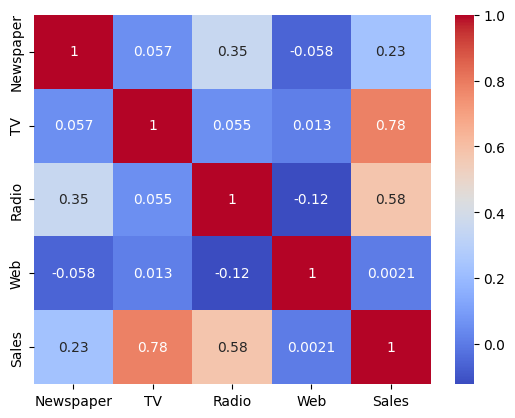

In [15]:
# matriz de correlación: mapa de calor
sns.heatmap(corr, annot = True,
            cmap = 'coolwarm',
            yticklabels=corr.columns,
            xticklabels=corr.columns)

In [16]:
ventas.head()

,Newspaper,TV,Radio,Web,Sales
0,46.0,204.1,32.9,245.774960,19.0
1,52.9,195.4,47.7,148.095134,22.4
2,114.0,67.8,36.6,202.638903,12.5
3,55.8,281.4,39.6,41.755313,24.4
4,18.3,69.2,20.5,210.489910,11.3


## <FONT SIZE=4 COLOR="purple"> 5.3 Modelos de regresión  </FONT>

Primero definimos la función de evaluación de los modelos.

In [17]:
# función para evaluar modelos de regresión
def evaluar_modelo(modelo, nombre_modelo, X_train, X_test, y_train, y_test):
    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Métricas train
    r2_train = r2_score(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)

    # Métricas test
    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    # DataFrame
    df_metricas = pd.DataFrame(
        [
            [r2_train, mse_train, rmse_train, mae_train],
            [r2_test, mse_test, rmse_test, mae_test]
        ],
        index=[f"{nombre_modelo}_train", f"{nombre_modelo}_test"],
        columns=["r2", "mse", "rmse", "mae"]
    )

    return df_metricas

In [18]:
# variable objetivo
y = ventas['Sales']
# variables predictoras
X = ventas.drop('Sales', axis=1)

# conjunto de entrenamiento y prueba
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               train_size=0.70,
                                               random_state=123)
# escalar los datos : para regresión lineal
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

### <FONT SIZE=4 COLOR="purple"> 5.3.1 Modelo de Regresión Lineal  </FONT>

In [19]:
# modelo de regresión lineal
modelo_linear = LinearRegression()
# entrenamiento
modelo_linear.fit(X_train_s,y_train)
# Evaluar el modelo
evaluacion_linear = evaluar_modelo(modelo_linear, "linear", X_train_s, X_test_s, y_train, y_test)
evaluacion_linear


,r2,mse,rmse,mae
linear_train,0.894959,2.819044,1.679001,1.257168
linear_test,0.910336,2.460491,1.568595,1.227604


In [ ]:
# variable objetivo : sales ud.
y.describe()

,Sales
count,200.000000
mean,14.022500
std,5.217457
min,1.600000
25%,10.375000
50%,12.900000
75%,17.400000
max,27.000000


In [ ]:
1.56 / (27-1.6)

0.061417322834645675

In [24]:
X_new = [45, 195, 30 , 240]
X_new_s = scaler.transform([X_new])
X_new_s
modelo_linear.predict(X_new_s)

array([17.71827409])

In [25]:
print(modelo_linear.intercept_)
print(modelo_linear.coef_)

14.192142857142859
[0.08769544 3.87261388 2.79697026 0.21198365]


Esto indica que:

$Sales = 14.19+0.08*Newspaper+ 3.87*TV+2.79*Radio+0.211*Web$

### <FONT SIZE=4 COLOR="purple"> 5.3.2 Modelo de KNN </FONT>

In [26]:
# librería
from sklearn.neighbors import KNeighborsRegressor
# modelo
modelo_knn = KNeighborsRegressor(n_neighbors=5)
# entrenamiento
modelo_knn.fit(X_train_s, y_train)
# evaluar el modelo
evaluacion_knn = evaluar_modelo(modelo_knn, "knn", X_train_s, X_test_s, y_train, y_test)
evaluacion_knn

,r2,mse,rmse,mae
knn_train,0.921166,2.115691,1.454542,1.005714
knn_test,0.921465,2.155107,1.468028,1.107333


### <FONT SIZE=4 COLOR="purple"> 5.3.3 Modelo de Árboles de Decisión  </FONT>

In [28]:
# modelo
modelo_tree = DecisionTreeRegressor(random_state= 0)
# entrenamiento
modelo_tree.fit(X_train, y_train)
# evaluar el modelo
evaluacion_tree = evaluar_modelo(modelo_tree, "tree", X_train, X_test, y_train, y_test)
evaluacion_tree

,r2,mse,rmse,mae
tree_train,1.000000,0.000000,0.00000,0.000000
tree_test,0.963735,0.995167,0.99758,0.808333


### <FONT SIZE=4 COLOR="purple"> 5.3.4 Modelo de SVR  </FONT>

In [29]:
# modelo
modelo_svr= SVR()
# entrenamiento
modelo_svr.fit(X_train_s, y_train)
# evaluar el modelo
evaluacion_svr = evaluar_modelo(modelo_svr,"svr", X_train_s, X_test_s, y_train, y_test)
evaluacion_svr

,r2,mse,rmse,mae
svr_train,0.882441,3.154988,1.776229,1.003616
svr_test,0.892223,2.957530,1.719747,1.177803


In [30]:
evaluacion_linear = evaluar_modelo(modelo_linear, "linear", X_train_s, X_test_s, y_train, y_test)
evaluacion_linear

,r2,mse,rmse,mae
linear_train,0.894959,2.819044,1.679001,1.257168
linear_test,0.910336,2.460491,1.568595,1.227604


### <FONT SIZE=4 COLOR="purple"> 5.3.5 Modelo de Random Forest </FONT>



In [32]:
# modelo
modelo_rf = RandomForestRegressor(random_state=0)
# entrenamiento
modelo_rf.fit(X_train, y_train)
# evaluar el modelo
evaluacion_rf = evaluar_modelo(modelo_rf, "rf", X_train, X_test, y_train, y_test)
evaluacion_rf

,r2,mse,rmse,mae
rf_train,0.995373,0.124167,0.352373,0.260193
rf_test,0.974979,0.686622,0.828627,0.649083


Ahora una tabla resumen con todas las métricas

In [37]:
# dataframe con todas las métricas
df_modelos = pd.concat([evaluacion_linear,
                        evaluacion_knn,
                        evaluacion_tree,
                        evaluacion_svr,
                        evaluacion_rf])

display(df_modelos.iloc[[0,2,4,6,8]])
display(df_modelos.iloc[[1,3,5,7,9]])

,r2,mse,rmse,mae
linear_train,0.894959,2.819044,1.679001,1.257168
knn_train,0.921166,2.115691,1.454542,1.005714
tree_train,1.000000,0.000000,0.000000,0.000000
svr_train,0.882441,3.154988,1.776229,1.003616
rf_train,0.995373,0.124167,0.352373,0.260193


,r2,mse,rmse,mae
linear_test,0.910336,2.460491,1.568595,1.227604
knn_test,0.921465,2.155107,1.468028,1.107333
tree_test,0.963735,0.995167,0.997580,0.808333
svr_test,0.892223,2.957530,1.719747,1.177803
rf_test,0.974979,0.686622,0.828627,0.649083


El modelo Random Forest presentó el mejor desempeño predictivo, alcanzando un $R^2=0.975$, un RMSE de $0.829$ y un MAE de $0.649$ en el conjunto de prueba. Además, la pequeña diferencia entre las métricas de entrenamiento y prueba sugiere una adecuada capacidad de generalización. Por lo tanto, Random Forest fue seleccionado como el modelo óptimo para este problema.

Podemos ver la importancia de las variables

In [38]:
# importancia de las variable en árboles de decisión
modelo_rf.feature_importances_
importancias = pd.Series(modelo_rf.feature_importances_,
                         index=X.columns
                         ).sort_values(ascending=False)
importancias

,0
TV,0.630467
Radio,0.355358
Newspaper,0.008451
Web,0.005724


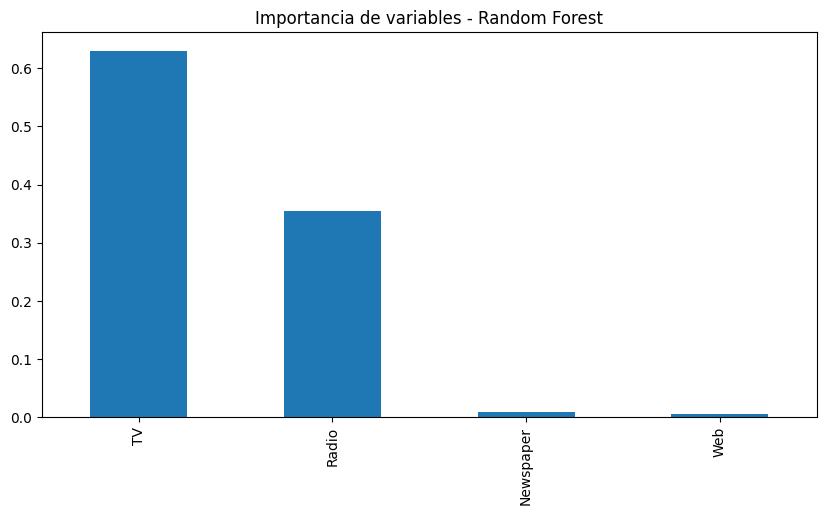

In [39]:
importancias.plot.bar(figsize=(10,5))
plt.title("Importancia de variables - Random Forest")
plt.show()

Interpretación:

- TV ($63.0\%$): es la variable más importante. La mayor parte de las decisiones de los árboles se basan en ella.

- Radio ($35.5\%$): también es muy relevante y aporta información adicional importante.

- Newspaper ($0.8\%$): prácticamente no contribuye al modelo.

- Web ($0.6\%$): tampoco parece aportar información útil.